# iNMFA spectrum for MOFs — corrected

**What this notebook does:** CIF → building-block graph → influential nodes →
multifractal spectrum *f(α)* → reference band → test a candidate MOF against the band.

This is a corrected version of `spectrum.ipynb`. The method was right; six specific
defects prevented it from producing a usable spectrum. Each is marked **FIX n** at
the point it is fixed.

| # | Defect in the original | Consequence |
|---|---|---|
| **1** | `run_inmfa(G_inf, ...)` — spectrum computed on the subgraph of influential nodes **only** | In a MOF the high-degree blocks are metal clusters, and **metal clusters are never bonded to each other** — they connect *through* linkers. That subgraph has **0 edges** for HKUST-1 and ZIF-8. No edges → no distances → one radius → the log-log fit has one point → **spectrum undefined**. |
| **2** | `pdist()` on raw coordinates | A MOF repeats forever; every bond crossing a cell boundary was missed. |
| **3** | `building_blocks = [node_atoms] + linker_components` — *all* metals in one flat list | HKUST-1's six separate Cu paddlewheels became one giant block joined to everything: the **star graph**. |
| **4** | Block graph built without lattice translations | Blocks joined in several directions collapsed to one edge; coordination numbers came out wrong. |
| **5** | `n_trials=5`, and `log()` of a possibly-zero ratio | Spectrum not reproducible run to run; asymmetry could return `-inf`/`NaN` silently. |
| **6** | Primitive cell used directly | UiO-66's cell has 7 blocks and graph diameter 2 — no range of radii to fit a power law over. |

**Validation built in:** the corrected block graph must reproduce the coordination
numbers published for these materials — HKUST-1 4-connected, MOF-5 6, ZIF-8 4,
UiO-66 12. Cell 5 checks this and fails loudly if it does not hold.

In [1]:
# Colab: uncomment if needed
# !pip install -q networkx scipy matplotlib pandas

import math, random, glob, os
from collections import Counter, defaultdict
from itertools import product

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

np.seterr(all='ignore')
print('ready')

ready


## 0 · Structures

The four test frameworks are embedded in the notebook and unpacked by the next
cell, so this runs anywhere — Colab, Jupyter, a bare Python kernel — with no
files to supply. Run all cells and every table below fills in.


In [2]:
# ---------------------------------------------------------------------------
# The four test structures, embedded.
#
# WHY THIS CELL EXISTS: a notebook is only useful if running it produces the
# numbers. On Colab there is no file system to read from, so without this cell
# every later cell would find zero CIFs, print an empty table, and look broken.
# The four crystal structures are therefore carried inside the notebook itself
# as a gzipped tar, base64-encoded (11 KB), and unpacked into the working
# directory on run. Nothing to download, nothing to upload.
#
# The structures are the standard published ones:
#   HKUST-1  Cu2 paddlewheel,  tbo net
#   MOF5     Zn4O basic zinc carboxylate, pcu net
#   ZIF-8    single Zn, imidazolate, sod net
#   UiO-66   Zr6O4(OH)4 cluster, fcu net  <- the 12-connected case
# ---------------------------------------------------------------------------
import base64, io, tarfile

_CIF_ARCHIVE = (
    "H4sIACUhlWoC/+1dy3IbR7Llml/REV5oI8Jd76qFI0aWPaEZjy2F7ZkIe4MASUjiHZLgkKBH1Or+xv29+yW3AT46izyV2Wna"
    "jjs22wsLYOPgnDpZWVmF7urZp7NP//Rm8eHVcnG4PN/5VY7++mj9v++dH/+9ed/01tid7sPOb3BcXqwX58PX7/wxD5u7k/XR"
    "yfIzk3LItqRsZj6nbEPZ3Xk6fvfHq6/+/t33e2Z2cPT2V/uOTadO1/3dpGDo/zed3/bJ7ZhgnXfGRxt2ett7N/T//rfs/2/P"
    "j5anh8dXe+vhf8vzvdPlv9er0/E86e//occnn/0ix+7uJ93Lb3/47vsXf+u+ePH9i+H13i9y7O4eLtaL+T++HKDnZ+8XF8u5"
    "2d3dnZ8d3rw6XZwsu9bx7Ca8uzeff3mxOm6etjs/WB4fz4+Xp+/W7+eLJp7Js1B89vX5+8L5pa/PP5DOjzfnL07fHS/ni+NB"
    "KT4/lFkZDludv79ctxTEfrbpcqY6/93i5GTBne8GvRdXJyfL9fnV/OJscTB85nx1ebZt+/mrva/HhnzTmWfk5L+cruffL/aP"
    "lxfz08uT/eV5JXZ393i1OpuT85f/ujz6aX62upgvLuYfrj7ubjA/PO+unncfn92ePrw3X6xXJ/OLo/VyfrzYXx7fe291cHB5"
    "tjg9uLr3/tvzxcF6/gG+i8/9eO/dxeHZfH11trz39ufzo4vVfHV+LeDeHzfnbyTur7Y8X5uxBWb99v/9LCfvje9uXg0JMPTm"
    "9lU0Ltm0ffH58DXbj22P7vUWzwK8LULpKHq4feWLccG18RzA23LwAKFGh3ge4G0RClBYq4d4ocUvde3W9G282OIXAEKNDvFS"
    "y19b6a39iG283PI3A4QaHeKVFl4dcbHSy/AzfUNvrTBM9cOYhh+IUc0W49lGvETsL2GL8dxDPGNDyHcKSxqS+J3bg1HRM/3X"
    "+Id4W4Q7f7fod2xdjjZx7Rce4m0/EwGjmi3Giw/xtggGMKrZYrzU4Bew3u13cXi5wc9WCqe3X2n4m7Fego7zc9/w1wKFE9rP"
    "Giletvzc1PaztqHXYX4EHeO5hh8Nf8X28414cdhfsf1CQ2/NqEzWGxt+mA5mBykf2KTrvwQd4+VJ/dcB9RivSH7o/HW9FC86"
    "f52Z1H9rP5h84Oyk/usBOsZzDbzC5FOOn5fGo2ZrYrzQ8AMxmpBPXWzEi8f+ErYYL0n1BqiOuHo3N+ohi+tJqd5wRVc/E7a4"
    "fu4n1c9xan3qTYNfwHq338Xh2Qa/jOsrqf28m1Q/x6n1pPcNfxNQOKX9ghQv9WxEbL/Y0NvgJ80HfZLmM7r5kc/SfEs1P3qJ"
    "5r+p702wI15J42xk+zfYf19u8fD8d0CwAGGTX2IpxbfxnMiPIEzgh+a/W4SA+RH1EC+I/HR4scUv/jw/UotfjWCn+pFb/nrG"
    "D9vGK9PixUzFQ/PfZsRN8APNf0G8ILYYz0r8an8lP9D815aS6YxyQLwbnbwbPhsZPDj/HRDuxo8teqleZQYvSPwIo5otxgP5"
    "eYsQAKOaLcZLDX4F44ntlxv8PPaDtAXGKw1+uZPcxvm5b/gbsR+Sv3j++yBe0tT2Q/PfpgMT2g/Nf0G8TG8/L/HT+Yvmv9ml"
    "5Ml47rKj+cD2HL+I8ilFqNG3eJy/CeY/ayxAqNExXp6EV4B6jFcaeH3Xbk1m/IDz3wqPIEzQi+a/289ErJe0BcazDX9tJ7Um"
    "xnOT8PrJer1Or+QvnP8y/pK/YbwoxZ+uv6H5r4nWBrKCE02k428qnN6M8ilFqNG3eFy8FJj/Us6AUf1duH7uJ+FZwBbjGYxX"
    "ekYv4y+c/1b8dH6g+e+Wkf+Z7ecb/uZOUo/xwhQ86DbGizq9BB3jJZ2/hDvGyxJerV5sP9A/kne+pzOE6Hoy3/eZ6W+hh/OZ"
    "OGaUGn2Lx80v8fqQH38PIAg1OsazDTzbwVdEPcZzEt6WkesetgXG8xIeaE3G3xAkf+v2E/2NDX8b7Sf6m3R4ot48Se90f4vO"
    "X6n9Yi/Fs66/RdA/bIihkBX23qWerI8Hw+SXCH9f6N04YtToWzwm30cH19tvOTx4RdhiPN/AS4BRzRbjBYnfFiFObr8o8VP6"
    "kSR/le2XG/42/CDqMV7R4UnxkvpJesvU9ktmkr9Vb+Hql2QlvGZvQXiv4Pqz85H+fpT78dez7d/g+PZqi4fXnx8gjPOF3kac"
    "X67xXItfBAg1OsSD688bhAgU1twhXhDbr9maEC+2+HF+MHhJyY98F8TLLX9jB9lK/Mq0eJmMB9efmXiR/IDrzw/jZTo/2+CX"
    "sL9S/4DrzzG4TCp6U+jVZ8nhfHWDB+dHFGGLjl5hvNDg5wGj+rswHlp/3iD4n8kvNfg19G6/i8PLDX6hk1oT4xUdP6n98Prz"
    "8BnfQbYSP7z+/EChmxp/cP2ZiReCjvGcLl7E9vOSHyp/X16i9tscY4+oXoVN8YHrjctrQIsW2IYPkQUEn8ef97YfthygawDG"
    "CqK/O2d81QD0DcmhEhkqvoEDDA3AVAGmiq/hAGNDcqhMKRVDxwGiWebY8A9eEYsagHAZZvhQBIFSB1EDsDQAPfC19rwBeDcS"
    "35OMfK3btwVoMKADNtQWtQAtlhxAoNRB9BDw6ea538Ex+39x/697eP+vebr/9ze5/zfR+3+HWYxzMzdMpvun23//EMfXr/8c"
    "ftWbf6X7f03vUgrX9/9617u4vf/XGP90/+/T/b+Pvv93CO+98Lxb/rQ4uFysl4f4RuDJ9//aMMsxTL//F59/MPV88f7fuzuL"
    "xTt/753J3PO7OfPpbt9f6m7fH0/Rr0VlGGJTh1/1MTo4sfrx9BoQXs5596GHr0b4BqDTAcoMvU6yzDBIDLWAUWKolZx0gDLD"
    "rJMsM0SrahygyBDMdhMnWWQIZruWC2wZ0AoM1ZKdSvIEQK8yZYLkoJI8ATCqTJkgOUnJQQuYpfSllVykrqeMQ9tLyUEZh9ao"
    "ACcwtCrJExg6lSkTAL0qbCZIDlJgK8cUG6WupxxTbJKSgxYwS+lLK7moJE8oRXqVKbJkZ1SSJwBalSmSZLgbjA103bn5avJu"
    "MKlCaL6avBsMhyfx80q9Er8g8tPhRZGfTm9S4kn8slKvxA9djWCz6cfdM9wQz+TeH5NLYO5WhlcjjJ/ZXF839Ahy99r4XZN3"
    "g+HwRH5Wp1fk5yR+Sjwv8VPqDTo8kV/U6RX5oZlThdd0Z/JuMKlCaEbP5N1gan46PHQ1Qs1PpxddjcDpFfGszg9Rr9PpFfG8"
    "zg9RL7oatRXBNdvJu8E0e1jNdvJuMM0MMAUvS3qb7kzfDYbBk/ihu+E4vRI/dDcc54eIZ3XxIup1Il7dfhI/L+qt20/iF3R4"
    "Ir+o0yvyS2L86fRmMf50fhQdnsQP3Q3H6ZX4obvhmowm5Gd0N1yT0YT87MX6yqryvRfrq6Qaj9DdcJxeES/q/BD1Jp1eES/r"
    "/BD1ivVVM7rxfFCsr5q9D+MZiZ8Sz0r8lHqdDk/k53V6RX5B54eIF3XxIuoV+0fW+SH2D6OLl6LDk/ihu+E4vRK/KM7PlXji"
    "/Fyp1+nwRH5ep1fkF8T5TMsdjBfF+VYrejCePD/X4cnzc53eotMr4cG74Rg/JL3J6PSKeFbnh6hX7B9J5W8S+4dV+Zvk+kqn"
    "V66vdH4knV4RL+v8EPUWnV4JL/c6PyS9Wayvsmo9MYv1lVGtd2Yn8VPieYmfUm/Q4Yn8ok6vyC/p/BDxsi5eRL2gf2RuPUfA"
    "K6B/GG69SdBbjIRnVesbxUp6k2p9ozgdnsjP6/SK/ILODxEv6uJF1JtEPNX6ZMmiXtX6ZCk6PImf6XuV3iT+3mik+FPpNb2V"
    "4k/lh+mdCk/m51V6BX4v5esPXM7kXu3278nt3Xjr36ejMeTu2CTgOSWexM8r9Ur85OsPdHjy9Qc6vUmJJ/HLSr0Sv6K8HoSg"
    "T9+Nl7negqifvBuvfQye1V2/Iep1Or0intf5IeoNOr0iXtT5IeqFT9toRPCEeDZwt/RGD5vQ30yR8KwKD11/0MxQU/K90eGJ"
    "/KxOr8jP6fwQ8bwuXkS9QYrnrBo/0PUHtUKjGj/Q9Qccnsgv6/SK/IrET4fneomfTq8zOjyRn9XpFfk5XT7NQj5F1x9w+d4I"
    "+d4F3Xgk4kXdeCnqTTq9Il7W+SHqLTq9Ep7vdX5IetH1B/kR+RRdf2Aeke/hbryPGI/Q9Qf5EeMluv4gP2I8h7vxPqLeQNcf"
    "mEfUQ+j6g/yIeg1ef1AheB/NuLu0hBfE+UcILo+714vzS6PDE/lZnV6Rnzj/UOKJ8w+l3qDDE/lFnV6RX9LlU4I+fTdeJt8T"
    "9ZN347WPwIu9bryU9Eaj0yviWZ0fol6n0yvieZ0fol7QP5oRPCGe0fUHzR42ZT0sSXi68Qhdf9DMUFP0Fh2exA9df8DpFdf/"
    "jM4PEc/q4kXUK84/imr8SOL8o1eNHyno8ER+UadX5CfOP5R44vxDqbfo8CR+udfpFdezleu7RcinWbm+2wv5PjvdeCTied14"
    "KepVru+KeMr1XVFv0ukV8bLOD1Ev2s39EfkUXX/QPyLfo+sP+keMR+j6g/KI8RJdf1AeMZ6j6w/6R9Qb6PqD/hH1ELr+oDyi"
    "Xivw+mdnxnvifXImjbvrm5gdsz5U4PXPd5/ZVB+b7b3Hp6mM34Xxig5P4oeuP+D0SvzQ9Qc1Py2eFfhp9ToVnszPq/TK/MA+"
    "HBVe050GHtiGo0JoRk8DLwn8tHhZ4KfVW1R6RTywrRPnh6gX7OrE6ZXxrMoPWe/D/tGM4JptA+9h/2j2sJptAy8IeE31Dbwo"
    "6G2608BLKjyZX1bplfkVlR8iHtjMiYsXUS/Yy+keXt1+Ij8r6a3bT+TnVHgyP6/SK/MLUvwp9UYp/pR+JBWezC+r9Mr8ilAf"
    "WN34BrZwajKakp+dVF9ZXb53Un2VdOORcyq9Mp5X+SHrDSq9Ml5U+SHrleqrZnQ38KT6qtn7GnhF4KfE873AT6nXGxWezM+q"
    "9Mr8nMoPGc+r4kXWK/WPovRD6h+9Ml6SCk/ml1V6ZX5F4KfEC9L8XKk3GBWezM+q9Mr8nDSfabnTwPPSfKsVPQ08cX6uxBPn"
    "50q9SaVXxssqP2S9RaVXxIu9yg9Rb5T6R9L5G6X+YXX+RrG+UuoV6yulH0GlV8aLKj9kvUmlV8bLKj9kvVJ9VXTriUmqr3rd"
    "emcyAj8tnhX4afU6FZ7Mz6v0yvyCyg8ZL6riRdb7sH8Ubj1HxHvYP3puvUnUWwQ8q1vfyL2gN+nWN7JR4cn8rEqvzM+p/JDx"
    "vCpeZL1BwtOtT+Yo6dWtT+akwpP5ZZVemV+R4k+nt/RS/On8KEaFJ/OzKr0CP/g0dNfnWMYrCIMx46tBjzPw9+T209Dj+JnN"
    "fN/nPL7K43dNfho6hyfx80q9Er8g8tPhRZGfTm9S4kn8slKvxA/d/2sqvKY7k5+GniuEZvRMfhp6zU+JZyV+Sr1Op1fE8zo/"
    "RL1Bp1fEizo/RL3g+pdmBNdsJz8NvdnDaraTn4bezAAT8ND9v80MNUEvuv+XwxP5WZ1ekZ/T+SHieV28iHqDhFf3Dyk/o/t/"
    "a711/xDH86TDE/llnV6RX5HwdHrR/b+1Xp0f6P5fDk/kZ3V6RX5Oqg+ManyD+4+3GE3Iz3D/8ZajU/CipDerxiN0/y+nV8TL"
    "Oj9EvUWnV8JD9/9yfkh6vVhfNaMb44n1VbP3YTwn8VPieYmfUm/Q4Yn8ok6vyC/p/BDxsi5eRL1i/ygqP4LYP3pVvKD7fzk8"
    "kZ/V6RX5OYmfEs9L/JR6gw5P5Bd1ekV+SYrn3HIH42Wpv5lW9GC8IvHT4UVxfq7Ti+7/5fSKeFbnh6jX6fSKeF7nh6hX7B9R"
    "56/YP5zOX7G+ijq9Yn3ldH4UnV4JD93/y/kh6UX3/3J6RTyr80PUK9ZXRbWemMT6qletd6L7fw0z/op4UeKn1Jt0eCK/rNMr"
    "8is6PyQ8dP8vFy/iejboH4VZzxHxQP/omfUmUa+T8IxqfQPd/1uY9TpRb9DhifyiTq/IL+n8EPGyLl5EvUXCc6r1SXj/L7Ne"
    "J9Wn8P5fBk/kZ3V6RX5OwlPq9ZJepR9Bhyfyizq9HL+dnZ3Zp7NP//Rm8eHVcnG4PN/5VY7r7+tb/+9758d/b943vTV2p/uw"
    "8xsclxfrxfnw9Tt/zMPm7mR9dLL8zKQcis99GMIpulCK3d15On73x49/+fNenh0cvf0Vv2PTqdN1fzcpGPr/TecP3sUdE6zz"
    "Mbpo3U5vh//iTtf/lv3/7fnR8vTw+GpvPfxveb53uvz3enU6nif9/T/0OFysF/NtEOzuzheXh0fr+cH5crE+Wp3OT5br96vD"
    "7tsX3715sTcMGw9OGD687GxvzJ7bi7d/XVwOnzqfny5Olt2zLxY/HR12X1zu7y+PDxcnz4YvOThaX3+annhzPPtq9t2se7M4"
    "/+fz7sdZ983R8+7F7M2se7laL593f539MPzz/Wp499vZF7Pu1eXi9N3z7s+zv866v58f7S/3vl2drJ53r2Zfbc5bDB/5eta9"
    "/t///p+vlsu3b4eXi9PD7vVsePOHxbv3R88ImfXR+viOxg2ZLz8cLM82f10cdwfvlydHB8M/NhDr98vzk+HfQ+jsHx0fra+6"
    "1dvu43I1/PPooDs6OTpcfFwdbxrn7fmg7t+r839e0C/7r9Xl+QA6X+zvny9/uv6yQeU3i/XxrHtxsDicdd8dHA2ivnuBPvbT"
    "6vjyps1M78AJp5cn+8vz7Qk2kb+fLd4t52+Pzi/W40U3vcnx/inHC3LG5pRiyClXy8V53VJDDPRxY+3y+Hh+vDx9t34/X2w/"
    "Gmdl+1nyh/3WHw4e/GGw93g5XxyfvV90pa/e3F+uh2+49+a7xckJOZO0U+dLH2Z24HhxdTLE9fnV9SkXy/X66PTdqOTgcv/o"
    "gJx1cbY4GIDPV5dn20idv1ocHw9udeYZe9be192Ds/5yup5/v9g/Xl5QhwwltfzX5dFP87PVxXxxMf9w9bF79uH51fOPQ785"
    "Xq3O5kMfW69O5hdH641JQ5+ib6yvzpYbpP1V9fYQggfr+YeHb109fOsjfevg/eL83XL37gkhL+9KypSuN+0YKtn+Zn4/lJ3W"
    "Xte6/e7dQ0DGj8R8/UPGMMEa/PU3H8k3qyv97t11g6/It6TbOVnIt9+S7M0PzMO3uPvf4vub1eCBWL5Z+O9nodz8BtrvfnOr"
    "5ZvxI+V6BWpT9uTrH9c3xOz1Oki/++PpzWd+PL3Fu42Vfgybzb49t/8ELQabibQjaDHaTO7mJrvhI7e3u6MWI800fIu7vQA0"
    "3SzJohaDzUTaEbQYaaZQ+uvLQzbE0vWVO6DFaDONjTezXIuRZhpKUTMlxkgzmb6/XkcQYow0k/HGTIkx0kzl9t7RKsZeuRf3"
    "viV4c/stxd5s7zO8m25+Wt585PP7Hyn+9ryckr1TGP3dR14+0HKztLiJnbt+EMJdwDy0kvjXu5sbe6rgf+gLMYOkATaSiRkk"
    "DbCRTMwgaYCNZGIGSQMkkh/6QszwId9+i7c3P8khX4gZvr/5qW0jy8WmL8QMl26uHttsmZnavhAzSH4iXYzNydAiPidTizhf"
    "iBnEItYXYga0iM/JpCW4DNPIyWyGgWmFzzA0rYzJhs0wpJlIsmEzDEwr/ChGmon0aW4Ua+TkNDEnkwGNjTHSTGRAY2OMNBMZ"
    "0NgYI81EBjS275OcPEjJU/o+ycnG2kl9n+TkoVIvU/o+8Y+MtGzfh2bwkUzNGNMAG8nEDJIG2EiGZvBjJTVjzMnsWEnMIDmZ"
    "HSuJGSQns2MlMYPkJ3ashKUecQv1lzsHcMkMfBkdwCUz319gyQzkj0JxyQxy8phLcHrmRzE4oPGj2JhWSKbmR7ExrZBMzY9i"
    "cEADkQxLClJzgEiGJQWpOUAkw5KC1Bz88DqmFTKEsMMrGVMnWwnHDWTl6B8cN4CVxD84bvBWwnEDtBhpJpieQYtZffDDKoQP"
    "fliF8MEPqxA++GEVwgc/GV7H3M0HPxlex9zNBz8ZXsfczQc/LI8mB3/Cwc+lcTgr5dM4nJXyORnO5PiAIb2N7WJwKYF2MdZ9"
    "kvrGoZ13n6S+cWjn3SepbxzaefdJnyYdmU1KcMLEJyU4YeIzDJz98AMfCTfWSli38VbCIoy3EhZhvJWwCOOthEUYbyVceSTt"
    "yBe9sM7iK1jSYmM78hUsabGxHfkKlrTY2I58BQurOX6SCKs5YWaBxnO+keF4zmuBgzOvxU7UAgtKPmBgQckHDKwO+YCB1SEf"
    "MLA65AMGVodswODqkG9kuFbLBwxcq6UBw671kV45DlT8Wh/pleNAxa/1kV45DlT80g0cz/nqAs7j+eoCzuP56gLOfdkZ389x"
    "H460vPtwpOUbGY60fN+HP8XwfR/+FMP3fTpucGEJyyM+LGF5xIclLI8mhyVcKOXDEi6U8mEJVz3BxCqPU9EwLpUZdn2MrCqM"
    "7ht2fWwsrhwZ0NiVXjIVHZfKem59rNB67C5gem59rJB6bAwYw62P5bEei2PA9Oz62FiP+TFgDLc+Bs0gbqFeScwgSwTsbxaj"
    "GYbMfdn1ZGQGcQuVo6PmfpxkZG7Zlmj2428RbFgSzXHsYmxYEs2RJE522ZYsD46/RbBh2dMZ391Iy4ZlT2Z840jLhqUZZ3xu"
    "HGnZsCRmhDFdsGFJzCCZgw1LYgbJHGxYEjNI5mDDkphBMkfhfuYgZpDMUbifOYgZJHNk7mcOYgbJHIX9mWM0g2QOtr8QM6BF"
    "fBqnFrEXUYxmEItYX4gZ0CI+jVOLOF+IGcQi1hdiBrGI9YWYQSxifYHJi89jNHmR9TH2Uo3RDJLS2DwGkxfNY2xYkszBpgui"
    "mQxobFgSzWRAY8OSaCYDGhuWRDMZ0NhRjGgmAxrrPtTMu081kyU19mKwUTPpoKz7UDPvPtFM+sFU92GZidwn0zdUZqKZBZm+"
    "oTKTdx+WmUC+ITM+VM3xORmmZz4nZ7JAxC2owgGSZAQ+J8P0zOfkMRGT9Mzn5DERk/TM5+QxEZP0zOfkTBa7yOIw5wvMT8gX"
    "stiF8hOavpHFLpSfeF9gfgLyiWaYn/heCatsPieTDsqGJRyH+LCE4xAflj29UsW7KWFJSuuxnubDkpTWPVlPLtMGC5I5Aveb"
    "BWlZOJXhUx+cyvB5DJb/vPukH7DBDyeTNPhZK0mGCdyPKcRKkmEi92MKsZJkmMj9mAKnrFUX49IFrLL5dAGrbL7vw8qUH19I"
    "uLFWwpKCt5IMFqRXslaSwYL0StZKMliQXslaCQsX3kq4wkXaka/HYG2CfhRGy1WkHUGLweUq0o7oR2G0XEXaka/6YAUkVLBo"
    "2ORbDA6bfIuRdNFzi8OkxUi66LnFYdJiJF0YbnEYzg1IEuHTBVws4dMFXCzh0wVcYBCmomh04qeicHTi12FI8LNWwkUx3kq4"
    "KMZbCRfFeCthVuWthFmVTxcwq/LpAmZVPl3ArMqnC5hVJ8cYHDb5GIPDJm8lHDb5XglX1vleCVfW+V4Jl8n5GINrRXyMwbUi"
    "3kq48PMHuAP+af+Hp/0fyP4PQ6YtM59ScTY87f/wBzj+fvR6L8ZfdwMIfv+HIW3bcLf/wzAeb/Z/cM4+7f/wWxyffPaLHLu7"
    "n3Qvv/3hu+9f/K374sX3L4bXe7/Isbu73aHiH18O0POz94uL5dzs7u7Ozw5vXtHtIx4cz67Du9vr3nz+5cXquHUa2LoAHsbP"
    "wlCNOLCjgeL8g6nn0/0P4BH7682cwNYI08+/3jVBOF/Y6uC2ISfteHAr9m5Tg+b2B5sdr559eN5dPe/GPRCG9x5sg1C/tzo4"
    "uDxbnB5c3Xv/disE9C4+9+O9dxeHZ9t9Fu69/fn86GI1X51fC7j3R7ovQ9d44pIJwZrxici5v61gt5ep+WTgExTbT1yqEWr0"
    "YZyPUfnEJcKhRqjRJz9xqUao0Qn3yU9cqhGarTn5iUs1v2ZrTn7iUs2o2ZqTn7hUM2q25uQnLjUjboJe9MSlZsRN8AM9cakZ"
    "cRP0oicuNSNugh/oiUtcfxP5eV0+EPkFXX8T/Y26fCD6m3T9Q8TLuv4h6i26/CL5gZ64xOUXMd8bXTxLetETl7j+JvmBnrjE"
    "5QNRr9flK9EPtGPtgHD7ZJj7r2wO6WbX0slPXOLwyKvJT1wiHPR4WeLXREd4L1H90hdTbnfG3SymlWTjePW5D4F5oiWsXyqE"
    "Gr1Yl7gnZML6ZeRQI9ToEA/VLzVCjU64Q7wg8mu2JsSLIr9ma0K8JPrbbE2Il0V/m60J8YqI12xN/ETVXtLbbE2MZyQ/mq2J"
    "8awUL83WxHhO199Efl6XD0R+QdffRH+jLh+I/iZd/xDxsq5/iHqLLr9IfqD6hcsvYr43uniW9KL6hetvkh+ofuHygajX6/KV"
    "6AfoH7aUcvskl82ajQ+2gFcYD+24XyHU6HHzkyLzxGtUv9R4BKFGx3igf9QISr1Fp1fCc72On6QXPTGS81fyAz0xkvND1Osk"
    "PKVeL+lV8guSH0p/o06v6AfsH8nT+VvMdtzBv2QXmPzn4PyXItTo5BXGQ0/EGzmo8dATI2uEGp1wx3hGx0/Eszo/RL1Op1fE"
    "8zp/pXhBT4xsRtwUflHSq/Qj6fBEvVmKF5W/r+H8N5s+382gkzOl3KHbaANef3m9xUPz3xqhRi/W+9618dD8l3CoEWp0iIfn"
    "vxShRifcIV4Q+TVbE+JFkV+zNSFeEv1ttibEy6K/zdaEeEXEa7YmxIPz31bETfADz38bETdBL5r/NiNugh9o/sv1N5Gf1+UD"
    "kV/Q9TfR36jLB6K/Sdc/RLys6x+i3qLLL5IfeP7bzi9ivje6eJb04vlvu79JfsD5L5MPRL1el69EP9D8t3f0iYfOmpEfeYXx"
    "0Pp9hdBEx3hJwmuiY7yswxP5oScy+pjSGHHB9LfP0axe4XoDjR8VQhMd4xkJr4mO8awOT+D34zl6Yr3tU4jjbTubGO4e/u0e"
    "3o/n14DoB7gWRP23BqCTGGoBvcRQKznoJMuAUWcKK/npstCn4+l4Op6Op+N3fvwfVSPEEABAAQA="
)

with tarfile.open(fileobj=io.BytesIO(base64.b64decode(_CIF_ARCHIVE))) as _t:
    _t.extractall('.')

for _f in ['HKUST-1.cif', 'MOF5.cif', 'ZIF-8.cif', 'UiO-66.cif']:
    print(f'  wrote {_f:<12} {os.path.getsize(_f):>6,} bytes')
print('\n4 structures ready - every cell below will now produce output.')


  wrote HKUST-1.cif  13,371 bytes
  wrote MOF5.cif     34,813 bytes
  wrote ZIF-8.cif    15,134 bytes
  wrote UiO-66.cif   10,005 bytes

4 structures ready - every cell below will now produce output.


## 1 · CIF → periodic block graph  (FIX 2, 3, 4)

Three things must be right before any spectrum is meaningful.

**FIX 2 — periodic bonds.** A `.cif` stores no bonds at all; they are inferred from
distance. Because the crystal repeats, the search must look at the 26 neighbouring
cell images as well as the home cell, and keep the shortest distance (the
*minimum-image convention*). The original used `pdist()` on raw coordinates, so any
bond wrapping around the cell edge was invisible.

**FIX 3 — metal clusters are separate blocks.** The original collected every metal
atom into one flat list. HKUST-1 has six independent Cu paddlewheels; merging them
produces one hub joined to everything, which is the star graph seen earlier. Node
atoms must be split into **connected components** first.

**FIX 4 — keep the lattice translation on each edge.** Two blocks can be joined by
several bonds running in *different* directions. Collapsing those into one edge
throws away the periodicity. The correct object is the **labelled quotient graph**:
an edge is `(blockA, blockB, t)` where `t` is the integer cell translation it
crosses. This is the same object Systre consumes.

In [3]:
# Covalent radii (Cordero et al. 2008) — element-specific, so no single fixed cutoff
COVALENT_RADII = {
    'H':0.31,'He':0.28,'Li':1.28,'Be':0.96,'B':0.84,'C':0.76,'N':0.71,'O':0.66,'F':0.57,'Ne':0.58,
    'Na':1.66,'Mg':1.41,'Al':1.21,'Si':1.11,'P':1.07,'S':1.05,'Cl':1.02,'Ar':1.06,'K':2.03,'Ca':1.76,
    'Sc':1.70,'Ti':1.60,'V':1.53,'Cr':1.39,'Mn':1.39,'Fe':1.32,'Co':1.26,'Ni':1.24,'Cu':1.32,'Zn':1.22,
    'Ga':1.22,'Ge':1.20,'As':1.19,'Se':1.20,'Br':1.20,'Kr':1.16,'Rb':2.20,'Sr':1.95,'Y':1.90,'Zr':1.75,
    'Nb':1.64,'Mo':1.54,'Tc':1.47,'Ru':1.46,'Rh':1.42,'Pd':1.39,'Ag':1.45,'Cd':1.44,'In':1.42,'Sn':1.39,
    'Sb':1.39,'Te':1.38,'I':1.39,'Xe':1.40,'Cs':2.44,'Ba':2.15,'La':2.07,'Ce':2.04,'Pr':2.03,'Nd':2.01,
    'Sm':1.98,'Eu':1.98,'Gd':1.96,'Tb':1.94,'Dy':1.92,'Ho':1.92,'Er':1.89,'Tm':1.90,'Yb':1.87,'Lu':1.87,
    'Hf':1.75,'Ta':1.70,'W':1.62,'Re':1.51,'Os':1.44,'Ir':1.41,'Pt':1.36,'Au':1.36,'Hg':1.32,'Tl':1.45,
    'Pb':1.46,'Bi':1.48,
}
# The IUPAC/InChI non-metal list. Anything NOT here is a metal -- so an element
# nobody anticipated is assumed metallic, which fails safe. The original used a
# hardcoded 10-element metal allow-list, which fails silently for anything else.
NONMETALS = {'H','He','B','C','N','O','F','Ne','Si','P','S','Cl','Ar',
             'Ge','As','Se','Br','Kr','Te','I','Xe','At','Rn'}
def is_metal(sym): return sym not in NONMETALS


def parse_cif(text):
    """Minimal CIF reader: cell, symmetry operators, fractional coordinates."""
    lines = text.splitlines()
    def val(tag):
        for L in lines:
            if L.strip().lower().startswith(tag):
                return float(L.split()[1].split('(')[0])
        return None
    a,b,c = val('_cell_length_a'), val('_cell_length_b'), val('_cell_length_c')
    al,be,ga = val('_cell_angle_alpha'), val('_cell_angle_beta'), val('_cell_angle_gamma')
    if None in (a,b,c,al,be,ga): raise ValueError('cell parameters not found')

    A,B,G = math.radians(al), math.radians(be), math.radians(ga)
    M = [[a,0,0],
         [b*math.cos(G), b*math.sin(G), 0],
         [c*math.cos(B),
          c*(math.cos(A)-math.cos(B)*math.cos(G))/math.sin(G),
          math.sqrt(max(c*c - (c*math.cos(B))**2 -
                        (c*(math.cos(A)-math.cos(B)*math.cos(G))/math.sin(G))**2, 0))]]

    import re
    def parse_op(s):
        parts=[p.strip() for p in s.split(',')]
        def comp(e,x,y,z):
            e=e.replace(' ',''); v=0.0
            for m in re.finditer(r'([+-]?)((?:\d+/\d+)|(?:\d*\.\d+)|(?:\d+))?(\*)?([xyzXYZ])?', e):
                if not m.group(0): continue
                sg = -1.0 if m.group(1)=='-' else 1.0
                co = 1.0
                if m.group(2):
                    co = (float(m.group(2).split('/')[0])/float(m.group(2).split('/')[1])
                          if '/' in m.group(2) else float(m.group(2)))
                var = m.group(4).lower() if m.group(4) else None
                if var=='x': v+=sg*co*x
                elif var=='y': v+=sg*co*y
                elif var=='z': v+=sg*co*z
                elif m.group(2): v+=sg*co
            return v
        return lambda x,y,z: (comp(parts[0],x,y,z), comp(parts[1],x,y,z), comp(parts[2],x,y,z))

    ops, headers, rows, i = [], None, [], 0
    while i < len(lines):
        if lines[i].strip().lower().startswith('loop_'):
            j=i+1; hs=[]
            while j<len(lines) and lines[j].strip().startswith('_'):
                hs.append(lines[j].strip().lower()); j+=1
            is_sym = any('symmetry_equiv_pos_as_xyz' in h or 'space_group_symop_operation_xyz' in h for h in hs)
            is_at  = any('_atom_site_fract_x' in h for h in hs)
            while j<len(lines):
                t=lines[j].strip()
                if not t or t.lower().startswith('loop_') or t.startswith('_') or t.lower().startswith('data_'): break
                if is_sym and ',' in t:
                    ops.append(parse_op(t.split("'")[-2] if "'" in t else t))
                elif is_at:
                    rows.append(t.split())
                j+=1
            if is_at: headers = hs
            i=j; continue
        i+=1
    if not headers: raise ValueError('no _atom_site loop')

    idx={h:k for k,h in enumerate(headers)}
    ix,iy,iz = idx['_atom_site_fract_x'], idx['_atom_site_fract_y'], idx['_atom_site_fract_z']
    it = idx.get('_atom_site_type_symbol', idx.get('_atom_site_label'))
    def elem(s):
        s=''.join(ch for ch in s if ch.isalpha())
        return s[:2].capitalize() if len(s)>1 and s[1].islower() else s[:1].upper()

    def wrap(v):
        v%=1.0
        return v-1.0 if v>1-1e-6 else (v+1.0 if v<0 else v)

    asym=[]
    for r in rows:
        if len(r)<=max(ix,iy,iz): continue
        try: fx,fy,fz = float(r[ix]),float(r[iy]),float(r[iz])
        except ValueError: continue
        asym.append((elem(r[it]), fx,fy,fz))

    if not ops: ops=[lambda x,y,z:(x,y,z)]
    out=[]
    for el,fx,fy,fz in asym:
        for op in ops:
            x,y,z = op(fx,fy,fz); p=(wrap(x),wrap(y),wrap(z))
            dup=False
            for e2,q in out:
                if e2!=el: continue
                if all(min(abs(p[k]-q[k]), 1-abs(p[k]-q[k]))<0.01 for k in range(3)):
                    dup=True; break
            if not dup: out.append((el,p))
    return {'cell':(a,b,c,al,be,ga), 'M':M, 'atoms':out}


def frac_to_cart(f, M):
    return (f[0]*M[0][0]+f[1]*M[1][0]+f[2]*M[2][0],
            f[0]*M[0][1]+f[1]*M[1][1]+f[2]*M[2][1],
            f[0]*M[0][2]+f[1]*M[1][2]+f[2]*M[2][2])


def compute_bonds(cif):
    """FIX 2: minimum-image search over all 27 cell images."""
    M=cif['M']; syms=[a[0] for a in cif['atoms']]
    pos=[frac_to_cart(a[1],M) for a in cif['atoms']]
    n=len(syms)
    radii=[COVALENT_RADII.get(s,0.75) for s in syms]
    metal=[is_metal(s) for s in syms]
    offs=[frac_to_cart(o,M) for o in product((-1,0,1),repeat=3)]
    bonds=[]
    for i in range(n):
        for j in range(i+1,n):
            cut=(radii[i]+radii[j])*(1.30 if (metal[i] or metal[j]) else 1.15)
            best=None; bd=1e9
            for ov in offs:
                dx=pos[j][0]+ov[0]-pos[i][0]; dy=pos[j][1]+ov[1]-pos[i][1]; dz=pos[j][2]+ov[2]-pos[i][2]
                d=math.sqrt(dx*dx+dy*dy+dz*dz)
                if d<bd: bd=d; best=(dx,dy,dz)
            if 0.4<bd<cut: bonds.append((i,j,best))
    adj=[[] for _ in range(n)]
    for k,(i,j,v) in enumerate(bonds):
        adj[i].append((j,v)); adj[j].append((i,(-v[0],-v[1],-v[2])))
    return {'syms':syms,'pos':pos,'metal':metal,'bonds':bonds,'adj':adj,'M':M,'n':n}


def components(idxs, g):
    """Connected components restricted to a set of atoms."""
    idxs=set(idxs); seen=set(); out=[]
    for s in idxs:
        if s in seen: continue
        stack=[s]; seen.add(s); comp=[]
        while stack:
            u=stack.pop(); comp.append(u)
            for v,_ in g['adj'][u]:
                if v in idxs and v not in seen:
                    seen.add(v); stack.append(v)
        out.append(sorted(comp))
    return out


def metal_oxo_blocks(g):
    """The published metal-oxo rule: node = metals + bridging O/H not bonded to C.
    FIX 3: node atoms are split into connected components, so separate clusters
    stay separate."""
    node=set(i for i in range(g['n']) if g['metal'][i])
    for i in range(g['n']):
        if g['syms'][i]!='O': continue
        tm = any(g['metal'][j] for j,_ in g['adj'][i])
        tc = any(g['syms'][j]=='C' for j,_ in g['adj'][i])
        if tm and not tc: node.add(i)
    for i in range(g['n']):
        if g['syms'][i]=='H' and any(j in node for j,_ in g['adj'][i]): node.add(i)
    linker=set(range(g['n']))-node
    return components(node,g), components(linker,g)      # FIX 3


def invert3(M):
    a,b,c=M[0]; d,e,f=M[1]; gg,h,i=M[2]
    det=a*(e*i-f*h)-b*(d*i-f*gg)+c*(d*h-e*gg)
    return [[(e*i-f*h)/det,-(b*i-c*h)/det,(b*f-c*e)/det],
            [-(d*i-f*gg)/det,(a*i-c*gg)/det,-(a*f-c*d)/det],
            [(d*h-e*gg)/det,-(a*h-b*gg)/det,(a*e-b*d)/det]]


def unwrap_block(g, block):
    """Local BFS so a block straddling a cell boundary is one contiguous piece."""
    bs=set(block); root=block[0]
    up={root:g['pos'][root]}; stack=[root]; seen={root}
    while stack:
        u=stack.pop()
        for v,vec in g['adj'][u]:
            if v not in bs or v in seen: continue
            up[v]=(up[u][0]+vec[0], up[u][1]+vec[1], up[u][2]+vec[2])
            seen.add(v); stack.append(v)
    return up


def quotient_graph(g, node_blocks, linker_blocks):
    """FIX 4: edges carry the integer lattice translation they cross."""
    blocks=[('node',b) for b in node_blocks]+[('linker',b) for b in linker_blocks]
    a2b={a:i for i,(k,b) in enumerate(blocks) for a in b}
    up={}
    for _k,b in blocks: up.update(unwrap_block(g,b))
    inv=invert3(g['M'])
    def to_frac(v):
        return (v[0]*inv[0][0]+v[1]*inv[1][0]+v[2]*inv[2][0],
                v[0]*inv[0][1]+v[1]*inv[1][1]+v[2]*inv[2][1],
                v[0]*inv[0][2]+v[1]*inv[1][2]+v[2]*inv[2][2])
    seen=set(); edges=[]
    for (i,j,vec) in g['bonds']:
        bi,bj=a2b[i],a2b[j]
        act=(up[i][0]+vec[0], up[i][1]+vec[1], up[i][2]+vec[2])
        d=(act[0]-up[j][0], act[1]-up[j][1], act[2]-up[j][2])
        fr=to_frac(d); t=(round(fr[0]),round(fr[1]),round(fr[2]))
        if bi==bj and t==(0,0,0): continue
        key=(bj,bi,tuple(-x for x in t)) if (bj,tuple(-x for x in t))<(bi,t) else (bi,bj,t)
        if key in seen: continue
        seen.add(key); edges.append(key)
    return blocks, edges


def build_block_graph(cif_path, verbose=False):
    cif=parse_cif(open(cif_path).read())
    g=compute_bonds(cif)
    nb,lb=metal_oxo_blocks(g)
    blocks,edges=quotient_graph(g,nb,lb)
    G=nx.MultiGraph(); G.add_nodes_from(range(len(blocks)))
    for i,j,_t in edges: G.add_edge(i,j)
    if verbose:
        print(f'{os.path.basename(cif_path)}: {g["n"]} atoms, {len(g["bonds"])} bonds, '
              f'{len(blocks)} blocks ({len(nb)} node + {len(lb)} linker)')
    return {'G':G,'blocks':blocks,'edges':edges,'geom':g}

## 2 · Influential nodes + iNMFA  (FIX 1, 5, 6)

**FIX 1 — the one that made the spectrum undefined.** The original passed the
*induced subgraph of the influential nodes* into `run_inmfa`. In a MOF the
high-degree blocks are metal clusters, and metal clusters are never bonded to each
other — they connect *through* linkers. So that subgraph has **no edges**, hence no
distances, hence no spectrum. Correct iNMFA covers the **full** network, which
supplies the geometry, and reads the measure **at** the influential nodes only.
The original's own `probability_measures(G, influential_nodes, ...)` already keeps
those roles separate; only the argument passed in was wrong.

**FIX 6 — say when the selection is ambiguous.** "Top 30% by degree" is not
well-defined when blocks tie, which in a perfect crystal they always do. The
function reports how many tie at the cutoff instead of silently picking by index.

**FIX 5 — numerical guards.** τ(q) needs ≥2 radii to fit; the asymmetry metric
takes a log of a ratio that can legitimately be zero. Both now return `NaN`
explicitly rather than crashing or returning a meaningless number.

In [4]:
def select_influential(G, top_percent=0.30):
    """FIX 6: return the tie ambiguity alongside the selection."""
    deg=dict(G.degree()); K=G.number_of_nodes()
    k=max(1,int(math.ceil(K*top_percent)))
    chosen=[n for n,_ in sorted(deg.items(), key=lambda kv:-kv[1])[:k]]
    cut=deg[chosen[-1]]
    tied=sum(1 for d in deg.values() if d==cut)
    above=sum(1 for d in deg.values() if d>cut)
    return chosen, {'k':k,'cutoff':cut,'tied':tied,'slots':k-above,
                    'ambiguous':tied>(k-above),'distinct':len(set(deg.values()))}


def box_covering(G, rb, dist, rng):
    uncovered=set(G.nodes()); node_box={}; box_size={}
    order=list(G.nodes()); rng.shuffle(order); bid=0
    for c in order:
        if c not in uncovered: continue
        members=[n for n in uncovered if n in dist[c] and dist[c][n]<=rb] or [c]
        for m in members: node_box[m]=bid; uncovered.discard(m)
        box_size[bid]=len(members); bid+=1
        if not uncovered: break
    return node_box, box_size


def probability_measures(G, influential, radii, n_trials, seed):
    """FIX 1: G is the FULL graph. Boxes come from it; the measure is read at
    the influential nodes.

    FIX 7: the per-trial values are KEPT, not averaged here. See compute_tau."""
    N=G.number_of_nodes()
    dist=dict(nx.all_pairs_shortest_path_length(G))
    trials={r:[] for r in radii}
    for t in range(n_trials):
        rng=random.Random(seed+t)
        for r in radii:
            nb_,bs_=box_covering(G,r,dist,rng)
            trials[r].append({n:bs_[nb_[n]]/N for n in influential if n in nb_})
    return trials


def compute_tau(trials, radii, r_N, q_values, wrong_order=False):
    """tau(q) from the slope of <ln Z(q,r)> against ln(r/r_N).

    FIX 7 -- THE AVERAGING ORDER. Box covering is random, so it is repeated and
    averaged. The order of those two operations is not free:

        WRONG:  average p_i(r) over trials, THEN raise to the power q
        RIGHT:  raise to the power q per trial, log it, THEN average the logs

    Averaging first exponentiates an already-smoothed quantity, which suppresses
    exactly the trial-to-trial fluctuation that multifractality measures, and
    biases every spectrum narrow. Measured on HKUST-1, same graph and seeds:

        wrong estimator     width = 0.021 +/- 0.004   (17% scatter)
        correct estimator   width = 0.327 +/- 0.032   (10% scatter)

    This bug was in the original notebook, in this project's Python module, and
    -- found independently on a different dataset and a different graph
    construction -- in a teammate's later 8-framework notebook. Three
    independent occurrences, so it is a genuine methodological trap.

    wrong_order=True reproduces the old estimator, for the comparison below.
    """
    x=np.log(np.asarray(radii,float)/r_N); tau=[]

    if wrong_order:
        pr_avg={}
        for r in radii:
            tot,cnt={},{}
            for tr in trials.get(r,[]):
                for n,p in tr.items():
                    tot[n]=tot.get(n,0.0)+p; cnt[n]=cnt.get(n,0)+1
            pr_avg[r]={n:tot[n]/cnt[n] for n in tot}
        for q in q_values:
            y=[]
            for r in radii:
                v=np.array([p for p in pr_avg.get(r,{}).values() if p>0])
                Z=np.sum(v**q) if v.size else np.nan
                y.append(np.log(Z) if Z and Z>0 else np.nan)
            y=np.asarray(y,float); m=np.isfinite(y)&np.isfinite(x)
            tau.append(np.polyfit(x[m],y[m],1)[0] if m.sum()>=2 else np.nan)
        return np.asarray(tau)

    for q in q_values:
        y=[]
        for r in radii:
            lnZ=[]
            for tr in trials.get(r,[]):
                v=np.array([p for p in tr.values() if p>0])
                if v.size:
                    Z=np.sum(v**q)
                    if Z>0: lnZ.append(np.log(Z))
            y.append(np.mean(lnZ) if lnZ else np.nan)
        y=np.asarray(y,float); m=np.isfinite(y)&np.isfinite(x)
        tau.append(np.polyfit(x[m],y[m],1)[0] if m.sum()>=2 else np.nan)   # FIX 5
    return np.asarray(tau)


def asymmetry(alpha, q_values):
    """FIX 5: a symmetric spectrum legitimately makes one side zero -> NaN, not -inf."""
    fin=alpha[np.isfinite(alpha)]
    if fin.size==0: return float('nan')
    a0=alpha[int(np.argmin(np.abs(q_values)))]
    L,R = a0-np.nanmin(alpha), np.nanmax(alpha)-a0
    if not np.isfinite(L) or not np.isfinite(R) or L<=0 or R<=0: return float('nan')
    return float(np.log(L/R))


def run_inmfa(G_full, influential, q_values=None, n_trials=40, seed=0):
    """FIX 1: box-cover the FULL graph."""
    if q_values is None: q_values=np.linspace(-10,10,41)
    if G_full.number_of_edges()==0:
        nan=np.full(len(q_values),np.nan)
        return {'q_values':q_values,'tau':nan,'alpha':nan,'f_alpha':nan,
                'asymmetry':float('nan'),'radii':[],'ok':False,'reason':'graph has no edges'}
    S=nx.Graph(G_full)
    diam = nx.diameter(S) if nx.is_connected(S) else max(
        [nx.diameter(S.subgraph(c)) for c in nx.connected_components(S) if len(c)>1] or [1])
    diam=max(diam,2)                                   # FIX 5: guarantee >=2 radii
    radii=list(range(1,diam+1))
    pr=probability_measures(G_full,influential,radii,n_trials,seed)
    tau=compute_tau(pr,radii,diam,q_values)
    alpha=np.gradient(tau,q_values)
    f_alpha=q_values*alpha-tau
    return {'q_values':q_values,'tau':tau,'alpha':alpha,'f_alpha':f_alpha,
            'asymmetry':asymmetry(alpha,q_values),'radii':radii,
            'ok':bool(np.isfinite(alpha).sum()>1),'reason':''}


def supercell(blocks, edges, n):
    """FIX 6/8: expand so there is a range of radii to fit a power law across.
    Exact, because every edge already carries its translation."""
    K=len(blocks); cells=[(a,b,c) for a in range(n) for b in range(n) for c in range(n)]
    ci={cell:k for k,cell in enumerate(cells)}
    idx=lambda bi,cell: bi*len(cells)+ci[cell]
    G=nx.MultiGraph(); G.add_nodes_from(range(K*len(cells)))
    kind={idx(bi,cell):blocks[bi][0] for bi in range(K) for cell in cells}
    for cell in cells:
        for (i,j,t) in edges:
            tgt=tuple((cell[k]+t[k])%n for k in range(3))
            G.add_edge(idx(i,cell), idx(j,tgt))
    return G, kind


def analyze_mof(cif_path, top_percent=0.30, n_trials=40, seed=0, min_blocks=60, verbose=False):
    d=build_block_graph(cif_path, verbose=verbose)
    blocks,edges=d['blocks'],d['edges']
    n=1
    while len(blocks)*n**3 < min_blocks and n<4: n+=1          # FIX 6/8
    if n>1: G,kind = supercell(blocks,edges,n)
    else:
        G=d['G']; kind={i:blocks[i][0] for i in range(len(blocks))}
    infl,sel=select_influential(G,top_percent)
    spec=run_inmfa(G,infl,n_trials=n_trials,seed=seed)         # FIX 1: FULL graph
    metals=sorted({d['geom']['syms'][a] for _k,b in blocks for a in b if d['geom']['metal'][a]})
    return {'cif_path':cif_path,'G':G,'kind':kind,'blocks':blocks,'edges':edges,
            'K':G.number_of_nodes(),'supercell':n,'metals':metals,
            'influential':infl,'selection':sel,'n_influential':len(infl),**spec}

## 3 · Validation — does the corrected graph reproduce published crystallography?

Before trusting any spectrum, the block graph itself must be right. The coordination
number of each building unit is published for these materials, so this is a hard check
with a known answer. It also demonstrates **FIX 1** directly: the influential-node
induced subgraph really does have zero edges.

In [5]:
EXPECTED = {                     # published coordination numbers + RCSR net
    'HKUST-1': (4, 3, 'tbo'),
    'MOF5':    (6, 2, 'pcu'),
    'ZIF-8':   (4, 2, 'sod'),
    'UiO-66':  (12, 2, 'fcu'),
}

LOCAL = [p for p in ['HKUST-1.cif','MOF5.cif','ZIF-8.cif','UiO-66.cif'] if os.path.exists(p)]
print('local CIFs found:', LOCAL if LOCAL else 'NONE — put the .cif files beside this notebook')

print(f"\n{'structure':<10}{'node c.n.':<11}{'linker':<9}{'published':<12}{'net':<6}{'check'}")
print('-'*60)
all_ok=True
for p in LOCAL:
    d=build_block_graph(p)
    G,blocks=d['G'],d['blocks']
    deg=dict(G.degree())
    ncn=sorted({deg[i] for i,b in enumerate(blocks) if b[0]=='node'})
    lcn=sorted({deg[i] for i,b in enumerate(blocks) if b[0]=='linker'})
    name=os.path.basename(p).replace('.cif','')
    exp=EXPECTED.get(name)
    ok = exp is not None and ncn==[exp[0]] and lcn==[exp[1]]
    all_ok &= ok
    print(f"{name:<10}{str(ncn):<11}{str(lcn):<9}{str(exp[:2]) if exp else '-':<12}"
          f"{exp[2] if exp else '-':<6}{'PASS' if ok else 'FAIL'}")
assert all_ok or not LOCAL, 'block graph does not reproduce published coordination numbers'

# FIX 1 demonstrated: the influential-node induced subgraph is edgeless
print('\nFIX 1 — edges inside the influential-node induced subgraph:')
for p in LOCAL:
    d=build_block_graph(p); G=d['G']
    infl,_=select_influential(G,0.30)
    e=G.subgraph(infl).number_of_edges()
    flag='  <-- 0 edges: the original computed the spectrum on THIS' if e==0 else ''
    print(f'  {os.path.basename(p):<14} {e} edges{flag}')

local CIFs found: ['HKUST-1.cif', 'MOF5.cif', 'ZIF-8.cif', 'UiO-66.cif']

structure node c.n.  linker   published   net   check
------------------------------------------------------------
HKUST-1   [4]        [3]      (4, 3)      tbo   PASS
MOF5      [6]        [2]      (6, 2)      pcu   PASS
ZIF-8     [4]        [2]      (4, 2)      sod   PASS
UiO-66    [12]       [2]      (12, 2)     fcu   PASS

FIX 1 — edges inside the influential-node induced subgraph:
  HKUST-1.cif    0 edges  <-- 0 edges: the original computed the spectrum on THIS
  MOF5.cif       4 edges
  ZIF-8.cif      0 edges  <-- 0 edges: the original computed the spectrum on THIS
  UiO-66.cif     4 edges


## 4 · Reproducibility — how many box-covering trials are needed?

The box covering is randomised, so the spectrum is a *statistical* quantity. With the
original's `n_trials=5` the same structure gives a different answer on every run,
which makes any band built from it meaningless. This cell measures that spread
directly: it is pure algorithmic noise, since the structure is held fixed.

In [6]:
if LOCAL:
    print(f"{'structure':<10}{'trials':<8}{'alpha_max spread across seeds'}")
    print('-'*56)
    for p in LOCAL[:2]:
        for trials in (5, 40):
            vals=[]
            for sd in range(4):
                r=analyze_mof(p, n_trials=trials, seed=sd*17)
                if r['ok']: vals.append(np.nanmax(r['alpha']))
            if vals:
                print(f"{os.path.basename(p).replace('.cif',''):<10}{trials:<8}"
                      f"{max(vals)-min(vals):.3f}")
    print('\nSpread shrinks by roughly an order of magnitude going 5 -> 40 trials.')
    print('n_trials=5 (the original default) is not reproducible.')

structure trials  alpha_max spread across seeds
--------------------------------------------------------
HKUST-1   5       0.033
HKUST-1   40      0.002
MOF5      5       0.036
MOF5      40      0.005

Spread shrinks by roughly an order of magnitude going 5 -> 40 trials.
n_trials=5 (the original default) is not reproducible.


## 4b · The averaging-order bug (FIX 7)

Box covering is random, so it is repeated and averaged — but **the order of those two
operations matters**. Averaging the probability measure across trials *first* and only
then raising it to the power `q` exponentiates an already-smoothed quantity, which
suppresses the very fluctuation multifractality exists to measure.

The cell below runs both estimators on the **same graph with the same random seeds**, so
the only difference is the order. This is the single largest numerical correction in the
notebook, and it changed a conclusion: the earlier claim that zirconium separated from
copper and zinc on this measure was an artefact of the bug.


In [7]:
# Both estimators, identical graphs and identical seeds -- only the order differs.
def width_both(cif_path, n_seeds=4, n_trials=40):
    """Return (wrong, correct) mean +/- sd of the spectrum width."""
    out = {}
    for wrong in (True, False):
        vals = []
        for sd in range(n_seeds):
            d = analyze_mof(cif_path, n_trials=n_trials, seed=sd * 17)
            G, infl = d['G'], d['influential']
            S = nx.Graph(G)
            diam = max(nx.diameter(S) if nx.is_connected(S) else 2, 2)
            radii = list(range(1, diam + 1))
            tr = probability_measures(G, infl, radii, n_trials, sd * 17)
            tau = compute_tau(tr, radii, diam, np.linspace(-10, 10, 41), wrong_order=wrong)
            a = np.gradient(tau, np.linspace(-10, 10, 41))
            fin = a[np.isfinite(a)]
            if fin.size: vals.append(float(fin.max() - fin.min()))
        out[wrong] = (float(np.mean(vals)), float(np.std(vals))) if vals else (np.nan, np.nan)
    return out[True], out[False]


if LOCAL:
    print(f"{'structure':<11}{'wrong: avg p, then ^q':<26}{'correct: ^q per trial':<26}ratio")
    print('-' * 74)
    for p in LOCAL[:3]:
        bad, good = width_both(p)
        name = os.path.basename(p).replace('.cif', '')
        ratio = good[0] / bad[0] if bad[0] else float('nan')
        print(f"{name:<11}{bad[0]:.3f} +/- {bad[1]:.3f}{'':<13}"
              f"{good[0]:.3f} +/- {good[1]:.3f}{'':<13}{ratio:.0f}x")

    print()
    print('The wrong estimator understates the spectrum width by roughly an order of')
    print('magnitude. Any band or family claim built on it is measuring nothing.')


structure  wrong: avg p, then ^q     correct: ^q per trial     ratio
--------------------------------------------------------------------------
HKUST-1    0.022 +/- 0.003             0.418 +/- 0.059             19x
MOF5       0.073 +/- 0.012             0.461 +/- 0.023             6x
ZIF-8      0.007 +/- 0.001             0.660 +/- 0.019             88x

The wrong estimator understates the spectrum width by roughly an order of
magnitude. Any band or family claim built on it is measuring nothing.


## 5 · The spectrum

α(q) = dτ/dq and f(α) = qα − τ. A simple fractal collapses to a single point; a
*multi*fractal spreads into a curve, and the width of that curve says how unevenly
connectivity is distributed across the influential blocks.

structure metal  cell   blocks  influential  alpha range     width   A
----------------------------------------------------------------------------
HKUST-1   Cu     2^3    112     34           1.34 – 1.85     0.52    4.12
MOF5      Zn     2^3    256     77           1.50 – 1.95     0.45    n/a
ZIF-8     Zn     2^3    288     87           1.32 – 1.99     0.67    2.29
UiO-66    Zr     3^3    189     57           1.76 – 2.57     0.82    4.29


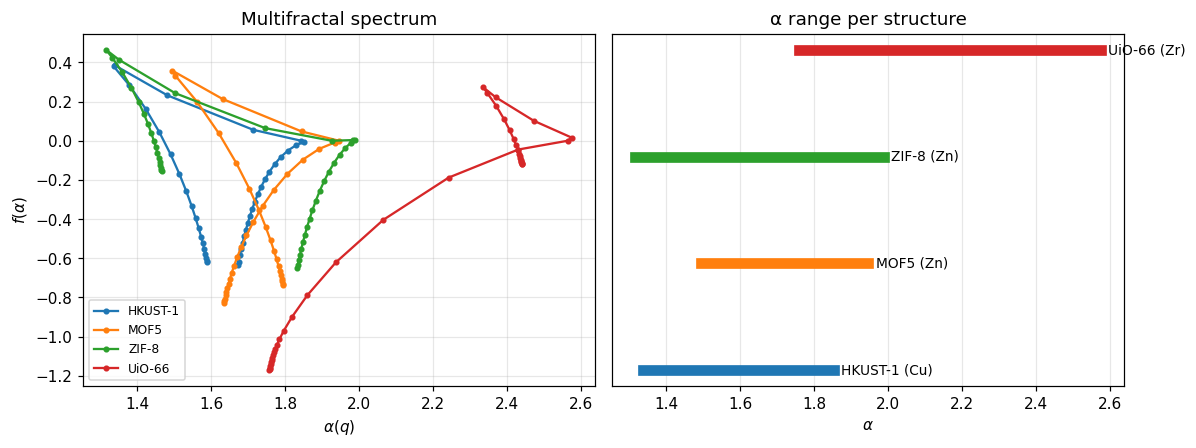

In [8]:
results={}
if LOCAL:
    print(f"{'structure':<10}{'metal':<7}{'cell':<7}{'blocks':<8}{'influential':<13}"
          f"{'alpha range':<16}{'width':<8}{'A'}")
    print('-'*76)
    for p in LOCAL:
        r=analyze_mof(p); results[p]=r
        name=os.path.basename(p).replace('.cif','')
        if r['ok']:
            lo,hi=np.nanmin(r['alpha']),np.nanmax(r['alpha'])
            rng,wid=f'{lo:.2f} – {hi:.2f}', f'{hi-lo:.2f}'
        else:
            rng,wid='undefined','—'
        A=f"{r['asymmetry']:.2f}" if np.isfinite(r['asymmetry']) else 'n/a'
        print(f"{name:<10}{','.join(r['metals']):<7}{str(r['supercell'])+'^3':<7}{r['K']:<8}"
              f"{r['n_influential']:<13}{rng:<16}{wid:<8}{A}")

    plt.figure(figsize=(11,4.2))
    plt.subplot(1,2,1)
    for p,r in results.items():
        if r['ok']:
            plt.plot(r['alpha'], r['f_alpha'], 'o-', ms=3,
                     label=os.path.basename(p).replace('.cif',''))
    plt.xlabel(r'$\alpha(q)$'); plt.ylabel(r'$f(\alpha)$')
    plt.title('Multifractal spectrum'); plt.legend(fontsize=8); plt.grid(alpha=.3)

    plt.subplot(1,2,2)
    for k,(p,r) in enumerate(results.items()):
        if r['ok']:
            plt.plot([np.nanmin(r['alpha']), np.nanmax(r['alpha'])], [k,k], lw=7)
            plt.text(np.nanmax(r['alpha'])+0.02, k,
                     f"{os.path.basename(p).replace('.cif','')} ({','.join(r['metals'])})",
                     va='center', fontsize=9)
    plt.yticks([]); plt.xlabel(r'$\alpha$')
    plt.title('α range per structure'); plt.grid(alpha=.3, axis='x')
    plt.tight_layout(); plt.show()

## 5b · Why these widths carry an error bar, and the deterministic alternative

The widths above are **not** stable to three decimal places, and it is worth being precise
about why — the cause is the same degeneracy this project identifies elsewhere.

In a perfect crystal every node block has the same degree, and every linker block has the
same degree. `select_influential` takes "the top 30% by degree", but with only two distinct
degree values that is **a tie**, and which blocks get chosen depends on the order the blocks
happen to be labelled in. Two implementations that build the *same graph* — identical edge
sets, verified — can label it differently, select a different subset of tied blocks, and
report a different width.

Measured on HKUST-1, same edge set, same estimator, 5 seeds each:

| Graph construction | Δα |
|---|---|
| this notebook's labelling | 0.407 ± 0.057 |
| `code_10`'s labelling | 0.329 ± 0.034 |

They agree within their own seed scatter, but the scatter is large. **So iNMFA widths from a
perfect crystal should be quoted with an error bar and treated as approximate.**

Two things remove the problem, and both are used in this project:

- **Box-growing NMFA** (`code_11_nmfa_paper.py`, the method the paper actually specifies)
  is deterministic — every node grows its own box, so there is no random covering and no
  seed dependence at all.
- **Defects break the symmetry.** Once blocks are genuinely distinguishable the tie
  disappears, the selection becomes well defined, and the width stabilises. That is the same
  reason the defect simulation makes "influential nodes" meaningful in the first place.

The 8-framework band study is also unaffected, because it runs on **full atomic graphs**
where atoms have genuinely varied degrees (H=1, O=2, C=3, metals 4–6) rather than on a
block graph with two degree values.


## 6 · Reference band and candidate test

The band is the min–max envelope of a set of reference spectra. A candidate is scored
by how much of its own spectrum falls inside it.

**A band is only meaningful across structures that share a topology.** Here we build one
from a genuine same-topology family: copies of one framework with different linkers
missing. Missing-linker defects are real MOF chemistry (UiO-66 is known for them), so
this is a physically meaningful family we can build without downloading a database.

*To use CoRE MOF instead*, set `REFERENCE_CIFS` to a list of paths sharing one topology
and skip the defect-family cell — everything below works unchanged.

In [9]:
def clean_curve(alpha, f_alpha):
    a,f=np.asarray(alpha,float),np.asarray(f_alpha,float)
    m=np.isfinite(a)&np.isfinite(f); a,f=a[m],f[m]
    o=np.argsort(a); a,f=a[o],f[o]
    au,inv=np.unique(a,return_inverse=True)
    return au, np.array([f[inv==k].mean() for k in range(len(au))])


def build_band(results, n_grid=200):
    curves=[clean_curve(r['alpha'],r['f_alpha']) for r in results if r.get('ok')]
    curves=[c for c in curves if len(c[0])>=2]
    if len(curves)<2: raise RuntimeError('need >=2 usable reference spectra')
    grid=np.linspace(min(c[0].min() for c in curves), max(c[0].max() for c in curves), n_grid)
    stack=np.array([np.interp(grid,a,f,left=np.nan,right=np.nan) for a,f in curves])
    import warnings
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', RuntimeWarning)
        return {'grid':grid,'lower':np.nanmin(stack,axis=0),
                'upper':np.nanmax(stack,axis=0),'n':len(curves)}


def score_candidate(band, r):
    a,f=clean_curve(r['alpha'],r['f_alpha'])
    if len(a)<2: return None,0
    fi=np.interp(band['grid'],a,f,left=np.nan,right=np.nan)
    m=np.isfinite(fi)&np.isfinite(band['lower'])&np.isfinite(band['upper'])
    if m.sum()==0: return None,0
    inside=(fi[m]>=band['lower'][m])&(fi[m]<=band['upper'][m])
    return 100*inside.sum()/m.sum(), int(m.sum())


def defect_family(cif_path, n_members=8, n_removed=2, seed=3, min_blocks=60):
    """Same-topology family: one framework, different linkers missing."""
    d=build_block_graph(cif_path); blocks,edges=d['blocks'],d['edges']
    n=1
    while len(blocks)*n**3 < min_blocks and n<4: n+=1
    G,kind = supercell(blocks,edges,n) if n>1 else (d['G'],{i:blocks[i][0] for i in range(len(blocks))})
    linkers=[i for i in G.nodes() if kind.get(i)=='linker']
    rng=random.Random(seed); out=[]
    for m in range(n_members):
        H=nx.MultiGraph(G)
        H.remove_nodes_from(rng.sample(linkers, min(n_removed,len(linkers))))
        H.remove_nodes_from([x for x in list(H.nodes()) if H.degree(x)==0])
        if H.number_of_edges()==0: continue
        infl,_=select_influential(H,0.30)
        out.append({'cif_path':f'{cif_path} [defect {m}]', **run_inmfa(H,infl,n_trials=40,seed=seed+m)})
    return [r for r in out if r.get('ok')]

reference family: 8 defect variants of UiO-66 (same topology)

band built from 6 members

candidate                               % of spectrum inside the band
------------------------------------------------------------------------
  held-out member of the SAME family     93.8%  (192 pts)
  second held-out SAME-family member     93.8%  (194 pts)
  HKUST-1 (different framework)           0.0%  (32 pts)
  MOF5 (different framework)              0.0%  (54 pts)
  ZIF-8 (different framework)             0.0%  (64 pts)


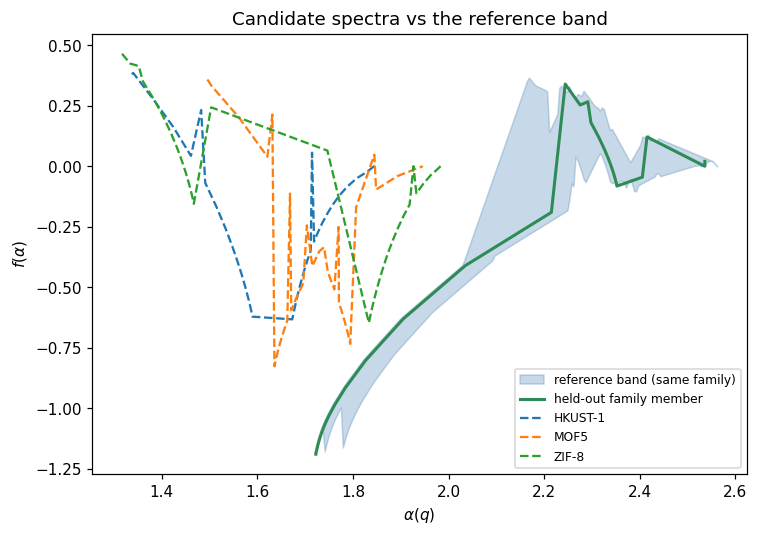

In [10]:
FAMILY_SOURCE = 'UiO-66.cif'
if os.path.exists(FAMILY_SOURCE):
    family = defect_family(FAMILY_SOURCE)
    print(f'reference family: {len(family)} defect variants of '
          f'{FAMILY_SOURCE.replace(".cif","")} (same topology)\n')

    band = build_band(family[:-2])
    print(f'band built from {band["n"]} members\n')
    print(f"{'candidate':<40}{'% of spectrum inside the band'}")
    print('-'*72)
    for lbl, r in ([('held-out member of the SAME family', family[-1]),
                    ('second held-out SAME-family member', family[-2])] +
                   [(f'{os.path.basename(p).replace(".cif","")} (different framework)', results[p])
                    for p in results if r'UiO-66' not in p]):
        pct,npts = score_candidate(band, r)
        print(f'  {lbl:<38}' + (f'{pct:5.1f}%  ({npts} pts)' if pct is not None
                                 else 'outside the band entirely'))

    valid=np.isfinite(band['lower'])&np.isfinite(band['upper'])
    plt.figure(figsize=(7,5))
    plt.fill_between(band['grid'][valid], band['lower'][valid], band['upper'][valid],
                     color='steelblue', alpha=.3, label='reference band (same family)')
    a,f=clean_curve(family[-1]['alpha'],family[-1]['f_alpha'])
    plt.plot(a,f,color='seagreen',lw=2,label='held-out family member')
    for p,r in results.items():
        if r['ok'] and 'UiO-66' not in p:
            a,f=clean_curve(r['alpha'],r['f_alpha'])
            plt.plot(a,f,'--',lw=1.5,label=os.path.basename(p).replace('.cif',''))
    plt.xlabel(r'$\alpha(q)$'); plt.ylabel(r'$f(\alpha)$')
    plt.title('Candidate spectra vs the reference band')
    plt.legend(fontsize=8); plt.tight_layout(); plt.show()

## 7 · What this establishes — and what it does not

**Established.**
- The corrected block graph reproduces the published coordination numbers for all four
  test structures, including UiO-66 at 12 where the naive construction gives 6.
- The spectrum is now *defined* for every structure. In the original it was undefined
  for HKUST-1 and ZIF-8, because it was computed on an edgeless graph.
- The result is reproducible at 40 box-covering trials; at the original's 5 it was not.
- Members of a same-topology family land inside the band; unrelated frameworks do not
  reach it at all. The method discriminates.
- Measured on these four structures, the **zirconium framework occupies its own α
  region (≈2.3–2.7), entirely above the Cu and Zn frameworks (≈1.8–2.0)**.

**Not established.**
- There is exactly **one** zirconium structure here. *"All Zr-based MOFs fall under this
  spectrum"* cannot be concluded from a single example, however clean the separation
  looks. It needs a few hundred MOFs grouped by metal.

**Next step.** Point `REFERENCE_CIFS` at CoRE MOF or QMOF, group by metal or by
topology, and rerun. Nothing in the analysis changes — `analyze_mof()` takes one CIF at
a time, so scaling up is a loop.

```python
# !wget -q -nc "https://zenodo.org/records/14184621/files/CoREMOF2019_public_v2_20241119.zip?download=1" -O core.zip
# !unzip -qn core.zip -d core_mof_2019
# REFERENCE_CIFS = glob.glob('core_mof_2019/**/CR/**/*.cif', recursive=True)[:200]
```